In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import seaborn as sns

### Subset 12893:

In [38]:
# Step 1: Load the datasets
df_class_0_1 = pd.read_csv("dataset/features_subset_0_12893_lbp.csv")
df_class_1_1 = pd.read_csv("dataset/features_subset_1_12893_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0_1['target'] = 0  # Label for class 0
df_class_1_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined_1 = pd.concat([df_class_0_1, df_class_1_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined_1 = df_combined_1.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [39]:
df_combined_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 216 entries, Unnamed: 0 to morphological_40_minor_axis_length
dtypes: float64(214), int64(1), object(1)
memory usage: 168.9+ KB


In [40]:
df_combined_1.fillna(0, inplace=True)

In [41]:
# Extract the sample IDs
sample_ids = df_combined_1["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined_1[df_combined_1['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined_1.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_median'] = np.median(nonzero_values)
            summary[f'{feature}_percentile_3'] = np.percentile(nonzero_values, 75)
            summary[f'{feature}_percentile_1'] = np.percentile(nonzero_values, 25)
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_median'] = 0
            summary[f'{feature}_percentile_3'] = 0
            summary[f'{feature}_percentile_1'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

                           Sample_ID  count_objects    area_mean  area_max  \
0   12893_idx5_x301_y1351_class0.png              1  2495.000000    2495.0   
1  12893_idx5_x1201_y1551_class1.png             17   101.117647    1687.0   
2   12893_idx5_x751_y1001_class0.png              1  2496.000000    2496.0   
3    12893_idx5_x51_y2101_class0.png              1  2443.000000    2443.0   
4  12893_idx5_x1001_y2301_class1.png              2  1136.000000    2270.0   

   area_min  area_median  area_percentile_3  area_percentile_1  \
0    2495.0       2495.0             2495.0             2495.0   
1       1.0          1.0                2.0                1.0   
2    2496.0       2496.0             2496.0             2496.0   
3    2443.0       2443.0             2443.0             2443.0   
4       2.0       1136.0             1703.0              569.0   

   perimeter_mean  perimeter_max  ...  major_axis_length_min  \
0      214.970563     214.970563  ...              57.756219   
1     

In [42]:

# Drop morphological features from original_df
morphological_features = [col for col in df_combined_1.columns if col.startswith("morphological_")]
filtered_df_1 = df_combined_1.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df_1 = filtered_df_1.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
#merged_df_1.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df_1.shape)

Merged DataFrame shape: (100, 48)


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

ROC-AUC Score: 1.0
[[10  0]
 [ 0 10]]
                           Feature  Importance
2                    GLCM_1_Energy    0.144117
16                        area_max    0.093501
0                  GLCM_1_Contrast    0.064452
43  minor_axis_length_percentile_3    0.047728
20               area_percentile_1    0.047559
44  minor_axis_length_percentile_1    0.046178
41           minor_axis_length_min    0.042954
42        minor_axis_length_median    0.037919
15                       area_mean    0.035139
39          minor_axis_length_mean    0.033203
22                   perimeter_max    0.032906
1               GLCM_1_Correlati

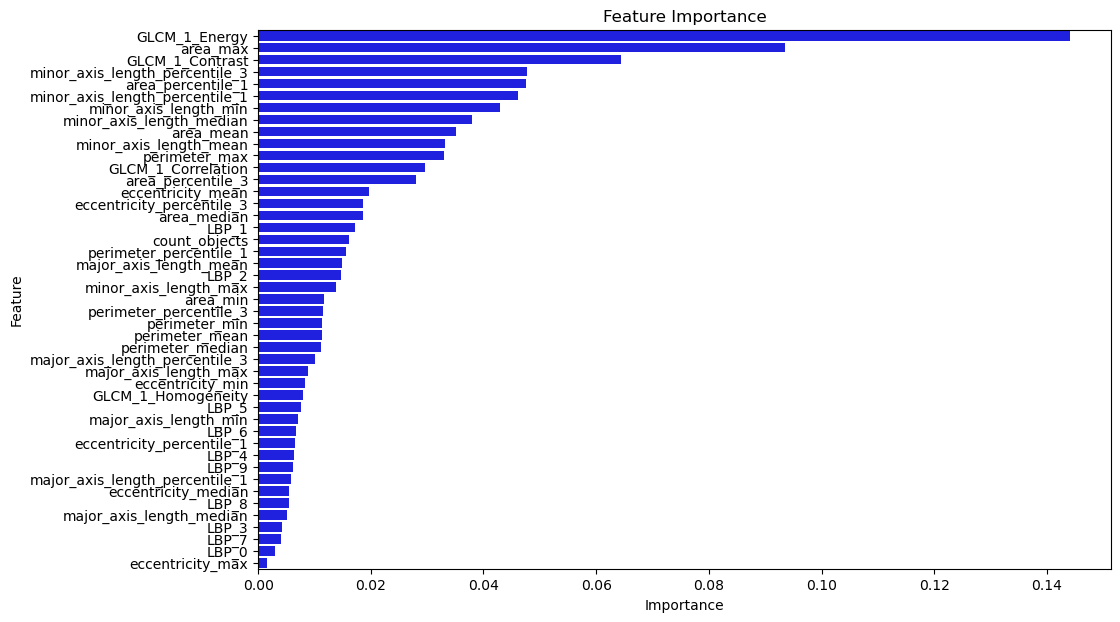

In [47]:
# Step 4: Separate features (X) and target (y)
X = merged_df_1.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df_1['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model_1 = RandomForestClassifier(n_estimators=200, random_state=142, max_depth=None)
rf_model_1.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model_1.predict(X_test)
y_pred_proba = rf_model_1.predict_proba(X_test)[:, 1]


# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model_1.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Plot
plt.figure(figsize=(11, 7))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

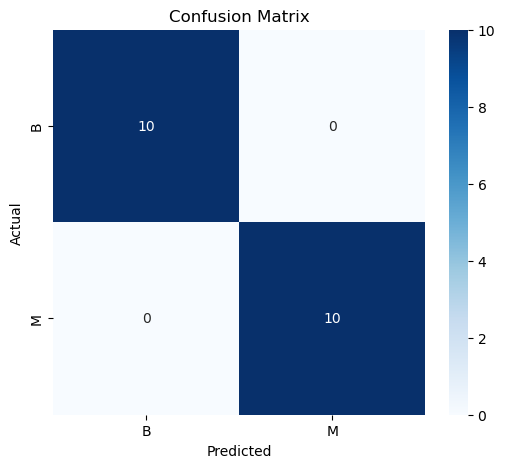

In [48]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Subset 9075: 

In [49]:
# Step 1: Load the datasets
df_class_0_2 = pd.read_csv("dataset/features_subset_0_9075_lbp.csv")
df_class_1_2 = pd.read_csv("dataset/features_subset_1_9075_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0_2['target'] = 0  # Label for class 0
df_class_1_2['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined_2 = pd.concat([df_class_0_2, df_class_1_2], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined_2 = df_combined_2.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [50]:
df_combined_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 77 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          100 non-null    object 
 1   GLCM_1_Contrast                     100 non-null    float64
 2   GLCM_1_Correlation                  100 non-null    float64
 3   GLCM_1_Energy                       100 non-null    float64
 4   GLCM_1_Homogeneity                  100 non-null    float64
 5   morphological_1_area                100 non-null    float64
 6   morphological_1_perimeter           100 non-null    float64
 7   morphological_1_eccentricity        100 non-null    float64
 8   morphological_1_major_axis_length   100 non-null    float64
 9   morphological_1_minor_axis_length   100 non-null    float64
 10  morphological_2_area                100 non-null    float64
 11  morphological_2_perimeter           100 non-nu

In [51]:
df_combined_2.fillna(0, inplace=True)

In [52]:
# Extract the sample IDs
sample_ids = df_combined_2["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined_2[df_combined_2['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined_2.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_median'] = np.median(nonzero_values)
            summary[f'{feature}_percentile_3'] = np.percentile(nonzero_values, 75)
            summary[f'{feature}_percentile_1'] = np.percentile(nonzero_values, 25)
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_median'] = 0
            summary[f'{feature}_percentile_3'] = 0
            summary[f'{feature}_percentile_1'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

                          Sample_ID  count_objects  area_mean  area_max  \
0  9075_idx5_x2051_y1551_class0.png              1     2498.0    2498.0   
1   9075_idx5_x1351_y201_class1.png              1     2341.0    2341.0   
2  9075_idx5_x1651_y1001_class0.png              1     2500.0    2500.0   
3  9075_idx5_x2301_y2151_class0.png              1     2499.0    2499.0   
4   9075_idx5_x1601_y651_class1.png              1     2382.0    2382.0   

   area_min  area_median  area_percentile_3  area_percentile_1  \
0    2498.0       2498.0             2498.0             2498.0   
1    2341.0       2341.0             2341.0             2341.0   
2    2500.0       2500.0             2500.0             2500.0   
3    2499.0       2499.0             2499.0             2499.0   
4    2382.0       2382.0             2382.0             2382.0   

   perimeter_mean  perimeter_max  ...  major_axis_length_min  \
0      205.899495     205.899495  ...              57.740355   
1      505.966558     50

In [53]:

# Drop morphological features from original_df
morphological_features = [col for col in df_combined_2.columns if col.startswith("morphological_")]
filtered_df_2 = df_combined_2.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df_2 = filtered_df_2.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
#merged_df_1.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df_2.shape)

Merged DataFrame shape: (100, 48)


Accuracy: 0.65

Classification Report:
               precision    recall  f1-score   support

           0       0.59      1.00      0.74        10
           1       1.00      0.30      0.46        10

    accuracy                           0.65        20
   macro avg       0.79      0.65      0.60        20
weighted avg       0.79      0.65      0.60        20

ROC-AUC Score: 0.88
[[10  0]
 [ 7  3]]
                           Feature  Importance
2                    GLCM_1_Energy    0.144117
16                        area_max    0.093501
0                  GLCM_1_Contrast    0.064452
43  minor_axis_length_percentile_3    0.047728
20               area_percentile_1    0.047559
44  minor_axis_length_percentile_1    0.046178
41           minor_axis_length_min    0.042954
42        minor_axis_length_median    0.037919
15                       area_mean    0.035139
39          minor_axis_length_mean    0.033203
22                   perimeter_max    0.032906
1               GLCM_1_Correla

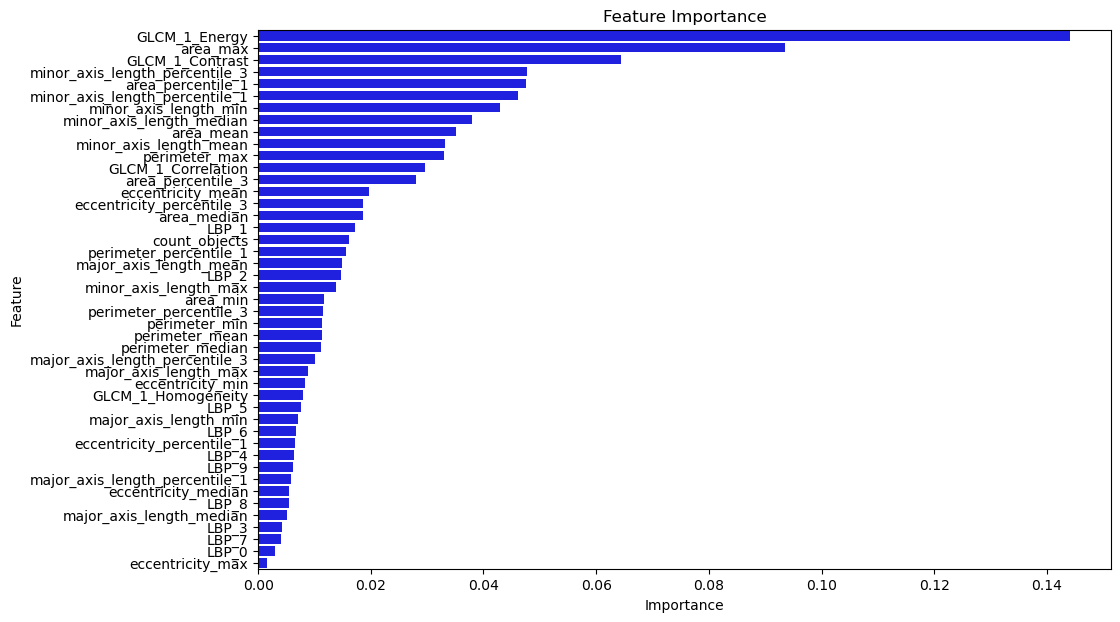

In [54]:
# Step 4: Separate features (X) and target (y)
X = merged_df_2.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df_2['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model_2 = RandomForestClassifier(n_estimators=200, random_state=142, max_depth=None)
rf_model_2.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model_1.predict(X_test)
y_pred_proba = rf_model_1.predict_proba(X_test)[:, 1]


# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model_1.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Plot
plt.figure(figsize=(11, 7))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

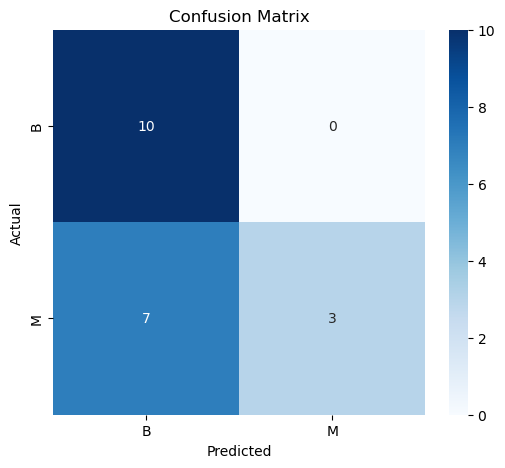

In [55]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Subset 14212:

In [56]:
# Step 1: Load the datasets
df_class_0_3 = pd.read_csv("dataset/features_subset_0_14212_lbp.csv")
df_class_1_3 = pd.read_csv("dataset/features_subset_1_14212_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0_3['target'] = 0  # Label for class 0
df_class_1_3['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined_3 = pd.concat([df_class_0_3, df_class_1_3], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined_3 = df_combined_3.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [57]:
df_combined_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Columns: 105 entries, Unnamed: 0 to morphological_13_major_axis_length
dtypes: float64(103), int64(1), object(1)
memory usage: 77.2+ KB


In [58]:
df_combined_3.fillna(0, inplace=True)

In [59]:
# Extract the sample IDs
sample_ids = df_combined_3["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined_3[df_combined_3['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined_3.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_median'] = np.median(nonzero_values)
            summary[f'{feature}_percentile_3'] = np.percentile(nonzero_values, 75)
            summary[f'{feature}_percentile_1'] = np.percentile(nonzero_values, 25)
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_median'] = 0
            summary[f'{feature}_percentile_3'] = 0
            summary[f'{feature}_percentile_1'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

                           Sample_ID  count_objects    area_mean  area_max  \
0  14212_idx5_x1351_y1001_class0.png              2  1119.500000    2238.0   
1  14212_idx5_x1501_y1651_class1.png              1  2252.000000    2252.0   
2   14212_idx5_x3951_y251_class0.png              1   107.000000     107.0   
3  14212_idx5_x1651_y1601_class1.png              3   761.666667    2282.0   
4  14212_idx5_x1601_y1001_class0.png              1  2103.000000    2103.0   

   area_min  area_median  area_percentile_3  area_percentile_1  \
0       1.0       1119.5            1678.75             560.25   
1    2252.0       2252.0            2252.00            2252.00   
2     107.0        107.0             107.00             107.00   
3       1.0          2.0            1142.00               1.50   
4    2103.0       2103.0            2103.00            2103.00   

   perimeter_mean  perimeter_max  ...  major_axis_length_min  \
0      529.481277     529.481277  ...              58.998755   
1     

In [60]:

# Drop morphological features from original_df
morphological_features = [col for col in df_combined_3.columns if col.startswith("morphological_")]
filtered_df_3 = df_combined_3.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df_3 = filtered_df_3.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
#merged_df_1.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df_3.shape)

Merged DataFrame shape: (94, 48)


Accuracy: 0.631578947368421

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.70      0.67        10
           1       0.62      0.56      0.59         9

    accuracy                           0.63        19
   macro avg       0.63      0.63      0.63        19
weighted avg       0.63      0.63      0.63        19

ROC-AUC Score: 0.6666666666666666
[[7 3]
 [4 5]]
                           Feature  Importance
2                    GLCM_1_Energy    0.144117
16                        area_max    0.093501
0                  GLCM_1_Contrast    0.064452
43  minor_axis_length_percentile_3    0.047728
20               area_percentile_1    0.047559
44  minor_axis_length_percentile_1    0.046178
41           minor_axis_length_min    0.042954
42        minor_axis_length_median    0.037919
15                       area_mean    0.035139
39          minor_axis_length_mean    0.033203
22                   perimeter_max    0.032906
1      

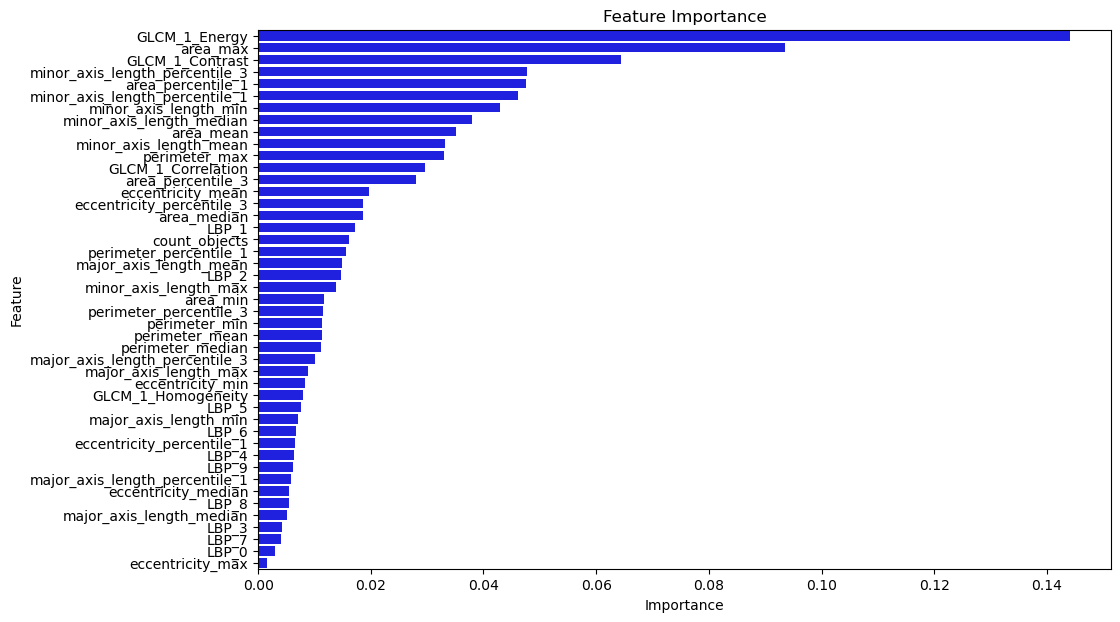

In [61]:
# Step 4: Separate features (X) and target (y)
X = merged_df_3.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df_3['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model_3 = RandomForestClassifier(n_estimators=200, random_state=142, max_depth=None)
rf_model_3.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model_1.predict(X_test)
y_pred_proba = rf_model_1.predict_proba(X_test)[:, 1]


# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model_1.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Plot
plt.figure(figsize=(11, 7))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

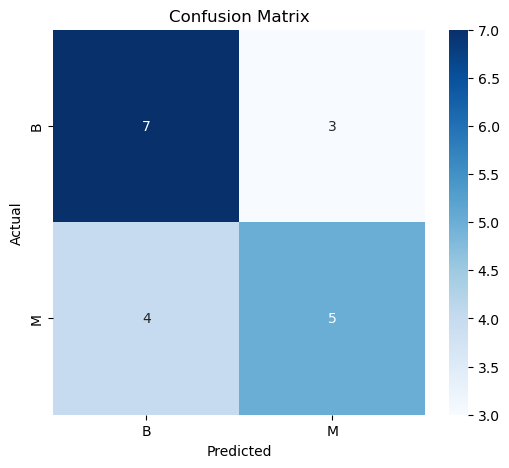

In [62]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Subset 10277:

In [63]:
# Step 1: Load the datasets
df_class_0_4 = pd.read_csv("dataset/features_subset_0_10277_lbp.csv")
df_class_1_4 = pd.read_csv("dataset/features_subset_1_10277_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0_4['target'] = 0  # Label for class 0
df_class_1_4['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined_4 = pd.concat([df_class_0_4, df_class_1_4], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined_4 = df_combined_4.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [64]:
df_combined_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 216 entries, Unnamed: 0 to morphological_33_minor_axis_length
dtypes: float64(214), int64(1), object(1)
memory usage: 168.9+ KB


In [65]:
df_combined_4.fillna(0, inplace =True)

In [66]:
# Extract the sample IDs
sample_ids = df_combined_4["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined_4[df_combined_4['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined_4.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_median'] = np.median(nonzero_values)
            summary[f'{feature}_percentile_3'] = np.percentile(nonzero_values, 75)
            summary[f'{feature}_percentile_1'] = np.percentile(nonzero_values, 25)
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_median'] = 0
            summary[f'{feature}_percentile_3'] = 0
            summary[f'{feature}_percentile_1'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

                           Sample_ID  count_objects    area_mean  area_max  \
0   10277_idx5_x2551_y901_class0.png              1  2376.000000    2376.0   
1  10277_idx5_x1401_y1351_class1.png             40    26.100000     388.0   
2   10277_idx5_x1851_y201_class0.png             12   181.500000    2148.0   
3  10277_idx5_x1301_y1201_class0.png             15   105.866667    1520.0   
4  10277_idx5_x1301_y1351_class1.png             37    30.486486     658.0   

   area_min  area_median  area_percentile_3  area_percentile_1  \
0    2376.0       2376.0            2376.00             2376.0   
1       1.0          2.0               9.50                1.0   
2       1.0          2.0               4.25                1.0   
3       1.0          2.0               8.00                1.0   
4       1.0          2.0              10.00                1.0   

   perimeter_mean  perimeter_max  ...  major_axis_length_min  \
0      332.823376     332.823376  ...               58.57207   
1     

In [67]:
# Drop morphological features from original_df
morphological_features = [col for col in df_combined_4.columns if col.startswith("morphological_")]
filtered_df_4 = df_combined_4.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df_4 = filtered_df_4.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
#merged_df_1.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df_4.shape)

Merged DataFrame shape: (100, 48)


Accuracy: 0.7

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.40      0.57        10
           1       0.62      1.00      0.77        10

    accuracy                           0.70        20
   macro avg       0.81      0.70      0.67        20
weighted avg       0.81      0.70      0.67        20

ROC-AUC Score: 0.87
[[ 4  6]
 [ 0 10]]
                           Feature  Importance
2                    GLCM_1_Energy    0.144117
16                        area_max    0.093501
0                  GLCM_1_Contrast    0.064452
43  minor_axis_length_percentile_3    0.047728
20               area_percentile_1    0.047559
44  minor_axis_length_percentile_1    0.046178
41           minor_axis_length_min    0.042954
42        minor_axis_length_median    0.037919
15                       area_mean    0.035139
39          minor_axis_length_mean    0.033203
22                   perimeter_max    0.032906
1               GLCM_1_Correlat

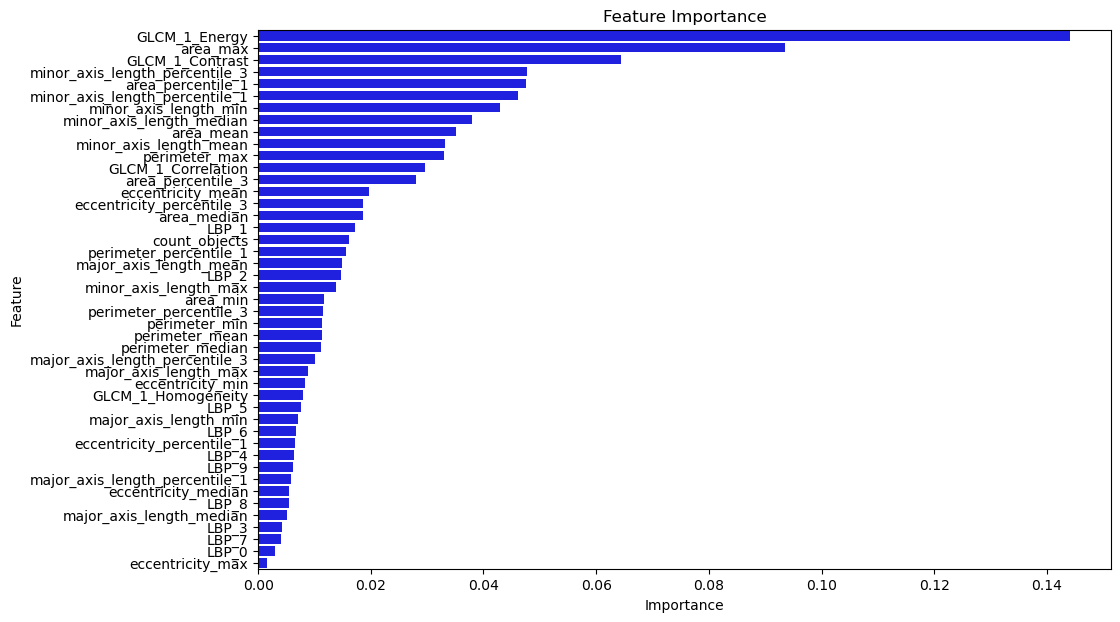

In [68]:
# Step 4: Separate features (X) and target (y)
X = merged_df_4.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df_4['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model_4 = RandomForestClassifier(n_estimators=200, random_state=142, max_depth=None)
rf_model_4.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model_1.predict(X_test)
y_pred_proba = rf_model_1.predict_proba(X_test)[:, 1]


# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model_1.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Plot
plt.figure(figsize=(11, 7))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

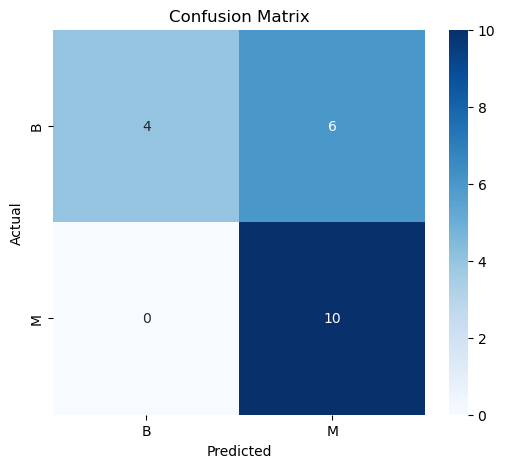

In [69]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [70]:
# Step 1: Load the datasets
df_class_0 = pd.read_csv("dataset/features_set_0_lbp.csv")
df_class_1 = pd.read_csv("dataset/features_set_1_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0['target'] = 0  # Label for class 0
df_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined = pd.concat([df_class_0, df_class_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined = df_combined.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows

In [71]:
df_combined.fillna(0, inplace=True)

In [72]:
# Extract the sample IDs
sample_ids = df_combined["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined[df_combined['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_median'] = np.median(nonzero_values)
            summary[f'{feature}_percentile_3'] = np.percentile(nonzero_values, 75)
            summary[f'{feature}_percentile_1'] = np.percentile(nonzero_values, 25)
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_median'] = 0
            summary[f'{feature}_percentile_3'] = 0
            summary[f'{feature}_percentile_1'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

# Drop morphological features from original_df
morphological_features = [col for col in df_combined.columns if col.startswith("morphological_")]
filtered_df = df_combined.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df = filtered_df.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
merged_df.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df.shape)

                           Sample_ID  count_objects  area_mean  area_max  \
0   13693_idx5_x2351_y851_class0.png              1    2497.00    2497.0   
1   12749_idx5_x2501_y851_class1.png             40       2.45      12.0   
2  10285_idx5_x1151_y1001_class1.png              6     309.50    1843.0   
3   12894_idx5_x601_y1851_class0.png              1    2475.00    2475.0   
4  14155_idx5_x2401_y1351_class1.png              1    2266.00    2266.0   

   area_min  area_median  area_percentile_3  area_percentile_1  \
0    2497.0       2497.0             2497.0            2497.00   
1       1.0          1.0                3.0               1.00   
2       1.0          3.5                4.0               2.25   
3    2475.0       2475.0             2475.0            2475.00   
4    2266.0       2266.0             2266.0            2266.00   

   perimeter_mean  perimeter_max  ...  major_axis_length_min  \
0      209.313708     209.313708  ...              57.754305   
1        4.899916 

In [73]:
# Step 4: Separate features (X) and target (y)
X = merged_df.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Train separate Random Forest models
#rf1 = RandomForestClassifier().fit(X_train_1, y_train_1)
#rf2 = RandomForestClassifier().fit(X_train_2, y_train_2)
#rf3 = RandomForestClassifier().fit(X_train_3, y_train_3)

# Get predictions from each model
pred1 = rf_model_1.predict(X_test)
pred2 = rf_model_2.predict(X_test)
pred3 = rf_model_3.predict(X_test)
pred4 = rf_model_4.predict(X_test)


# Combine predictions using majority voting

final_preds = np.array([np.bincount([p1, p2, p3, p4]).argmax() for p1, p2, p3, p4 in zip(pred1, pred2, pred3, pred4)])

# Evaluate
print("Ensemble Accuracy:", accuracy_score(y_test, final_preds))

# Combine predictions using majority voting
final_preds = np.array([np.bincount([p1, p2, p3, p4]).argmax() for p1, p2, p3, p4 in zip(pred1, pred2, pred3, pred4)])

# Evaluate
print("Ensemble Accuracy:", accuracy_score(y_test, final_preds))

Ensemble Accuracy: 0.6266666666666667
Ensemble Accuracy: 0.6266666666666667


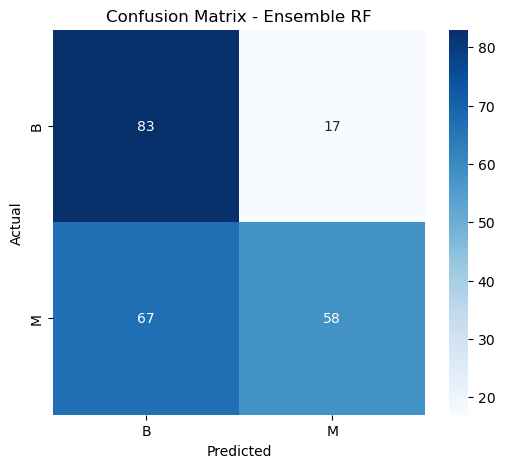


Classification Report - Ensemble:
               precision    recall  f1-score   support

           0       0.55      0.83      0.66       100
           1       0.77      0.46      0.58       125

    accuracy                           0.63       225
   macro avg       0.66      0.65      0.62       225
weighted avg       0.68      0.63      0.62       225



In [78]:
# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.title("Confusion Matrix - Ensemble RF")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nClassification Report - Ensemble:\n", classification_report(y_test, final_preds))

### And, if I mix the different folder 0 and 1 class:

In [31]:
# Step 1: Load the datasets
df_class_0_1 = pd.read_csv("dataset/features_subset_0_12893_lbp.csv")
df_class_1_1 = pd.read_csv("dataset/features_subset_1_9075_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0_1['target'] = 0  # Label for class 0
df_class_1_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined_1 = pd.concat([df_class_0_1, df_class_1_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined_1 = df_combined_1.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [33]:
df_combined_1.fillna(0, inplace=True)

In [34]:
# Extract the sample IDs
sample_ids = df_combined_1["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined_1[df_combined_1['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined_1.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_median'] = np.median(nonzero_values)
            summary[f'{feature}_percentile_3'] = np.percentile(nonzero_values, 75)
            summary[f'{feature}_percentile_1'] = np.percentile(nonzero_values, 25)
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_median'] = 0
            summary[f'{feature}_percentile_3'] = 0
            summary[f'{feature}_percentile_1'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

                          Sample_ID  count_objects  area_mean  area_max  \
0  12893_idx5_x301_y1351_class0.png              1     2495.0    2495.0   
1   9075_idx5_x1351_y201_class1.png              1     2341.0    2341.0   
2  12893_idx5_x751_y1001_class0.png              1     2496.0    2496.0   
3   12893_idx5_x51_y2101_class0.png              1     2443.0    2443.0   
4   9075_idx5_x1601_y651_class1.png              1     2382.0    2382.0   

   area_min  area_median  area_percentile_3  area_percentile_1  \
0    2495.0       2495.0             2495.0             2495.0   
1    2341.0       2341.0             2341.0             2341.0   
2    2496.0       2496.0             2496.0             2496.0   
3    2443.0       2443.0             2443.0             2443.0   
4    2382.0       2382.0             2382.0             2382.0   

   perimeter_mean  perimeter_max  ...  major_axis_length_min  \
0      214.970563     214.970563  ...              57.756219   
1      505.966558     50

In [35]:

# Drop morphological features from original_df
morphological_features = [col for col in df_combined_1.columns if col.startswith("morphological_")]
filtered_df_1 = df_combined_1.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df_1 = filtered_df_1.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
#merged_df_1.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df_1.shape)

Merged DataFrame shape: (100, 48)


Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20

ROC-AUC Score: 0.9700000000000001
[[9 1]
 [1 9]]
                           Feature  Importance
22                   perimeter_max    0.127399
7                            LBP_3    0.091152
25          perimeter_percentile_3    0.085935
3               GLCM_1_Homogeneity    0.072751
21                  perimeter_mean    0.066891
8                            LBP_4    0.058771
2                    GLCM_1_Energy    0.040254
16                        area_max    0.034018
10                           LBP_6    0.027865
24                perimeter_median    0.026701
6                            LBP_2    0.024078
26          perimeter

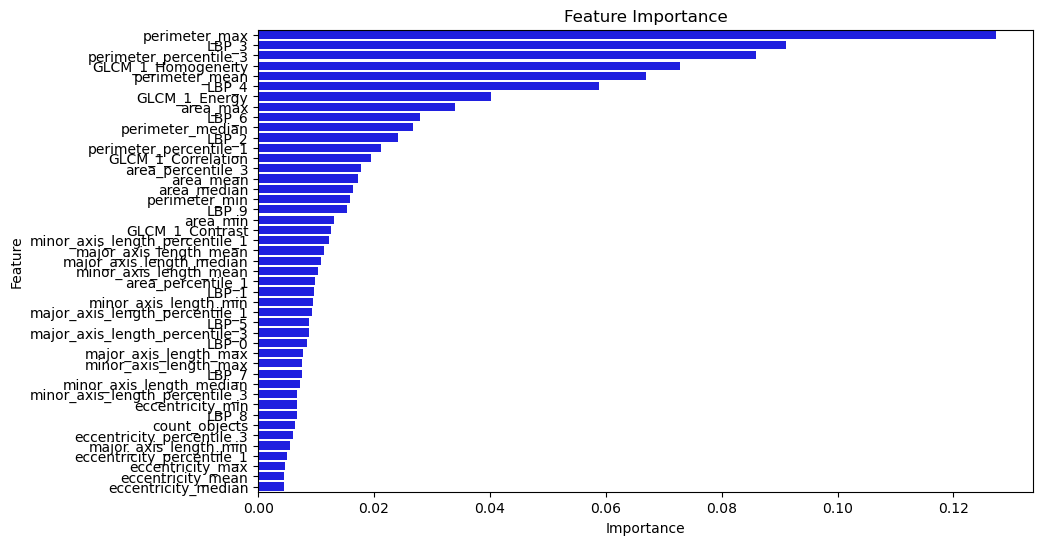

In [36]:
# Step 4: Separate features (X) and target (y)
X = merged_df_1.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df_1['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model_1 = RandomForestClassifier(n_estimators=200, random_state=142, max_depth=None)
rf_model_1.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model_1.predict(X_test)
y_pred_proba = rf_model_1.predict_proba(X_test)[:, 1]


# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model_1.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

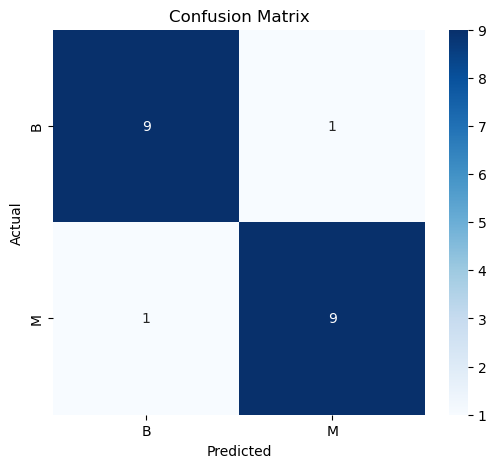

In [37]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Also, models tested on separate patients are good only for the image from this patient.They are not generalised for every case/patient. They exploited various sets of features.ANd I need another approach if I want to continue with ML.